### Problem Definition
- **What problem are we solving?** Predicting who survived the Titanic disaster.
- **Why is this problem important?** It is the classic introductory ML problem for understanding binary classification and feature importance.
- **What type of ML problem is this?** Supervised Binary Classification.

---

### Dataset
- **What information does this dataset contain?** Passenger demographics and ticket classes.
- **What is the target?** Survived (0 = No, 1 = Yes).

In [82]:
import pandas as pd

df = pd.read_csv('./data/Titanic-Dataset.csv')

### Exploratory Data Analysis
- **What should we learn from EDA?** The survival rates across different demographics.
- **Which features immediately look informative?** `Sex` and `Pclass` (Class) traditionally dictate survival due to the "women and children first" historical protocol.

In [83]:
import pandas as pd

pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)

# print(df)

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Deck'] = df['Cabin'].str[0]

df['Deck'] = df['Deck'].fillna('Unknown')

df.drop(columns=['Cabin', 'PassengerId', 'Ticket'], axis=1, inplace=True)


print(df.isna().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN  

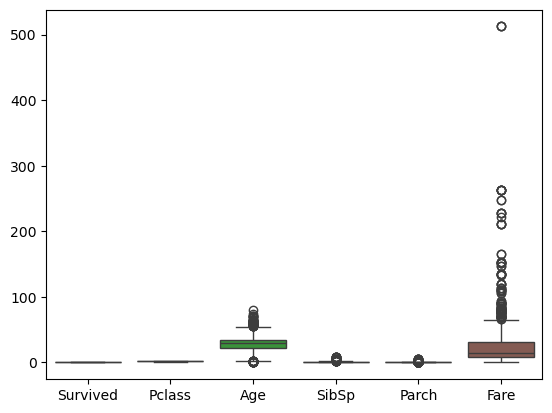

Lower bound: -26.724 
 Upper bound: 65.6344


In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df.select_dtypes(include='number'))
plt.show()

q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

IQR = q3 - q1
Lower_bound = q1 - 1.5 * IQR
Upper_bound = q3 + 1.5 * IQR

print(f'Lower bound: {Lower_bound} \n Upper bound: {Upper_bound}')

outliers_df = df[(df['Fare'] < Lower_bound) | (df['Fare'] > Upper_bound)]

# print(outliers_df[
#     (outliers_df['Pclass'] == 1) |
#     ((outliers_df['SibSp'] > 1) &
#     (outliers_df['Parch'] > 1))
# ])


### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

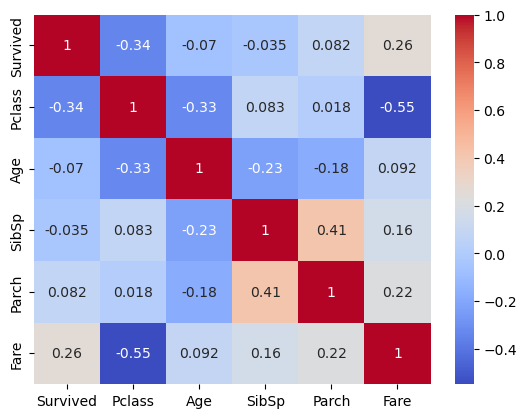

In [85]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


# sns.pairplot(
#     df.select_dtypes(include='number'), 
#     kind='reg', 
#     plot_kws={'line_kws':{'color':'red'}}
# )
# plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [86]:
import re as re

df['Family_size'] = df['SibSp'] + df['Parch'] + 1

df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')

title_mapping = {
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss", "Master": "Master",
    "Don": "Mr", "Rev": "Mr", "Dr": "Mr", "Mme": "Mrs", 
    "Ms": "Miss", "Major": "Mr", "Lady": "Mrs", "Sir": "Mr", 
    "Mlle": "Miss", "Col": "Mr", "Capt": "Mr", "the Countess": "Mrs", 
    "Jonkheer": "Mr", "Dona": "Mrs"
}

df['Title'] = df['Title'].map(title_mapping)

print(df['Title'].value_counts())

df.drop('Name', axis=1, inplace=True)

df['age_range'] = pd.cut(
    df['Age'], 
    bins=[0, 12, 19, 55, 120], 
    labels=['Child', 'Teen', 'adult', 'senior'],
    include_lowest=True)

print(df[['age_range', 'Age']])

Title
Mr        538
Miss      185
Mrs       127
Master     40
Name: count, dtype: int64
    age_range        Age
0       adult  22.000000
1       adult  38.000000
2       adult  26.000000
3       adult  35.000000
4       adult  35.000000
5       adult  29.699118
6       adult  54.000000
7       Child   2.000000
8       adult  27.000000
9        Teen  14.000000
10      Child   4.000000
11     senior  58.000000
12      adult  20.000000
13      adult  39.000000
14       Teen  14.000000
15      adult  55.000000
16      Child   2.000000
17      adult  29.699118
18      adult  31.000000
19      adult  29.699118
20      adult  35.000000
21      adult  34.000000
22       Teen  15.000000
23      adult  28.000000
24      Child   8.000000
25      adult  38.000000
26      adult  29.699118
27       Teen  19.000000
28      adult  29.699118
29      adult  29.699118
30      adult  40.000000
31      adult  29.699118
32      adult  29.699118
33     senior  66.000000
34      adult  28.000000
35      adul

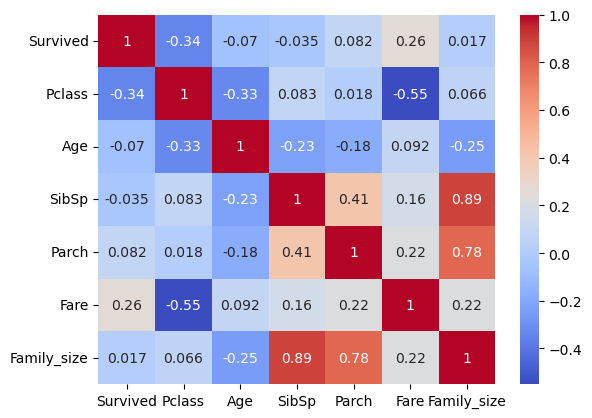

In [87]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

### Data Preprocessing
- **Missing value handling:** Age contains many nulls. We must impute (fill) these values to avoid throwing away valuable passenger rows.

In [88]:
import numpy as np

X = df.drop(columns='Survived')
y = df['Survived']

print(X.select_dtypes(include='number').skew())
print(y.skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

Pclass        -0.630548
Age            0.434488
SibSp          3.695352
Parch          2.749117
Fare           4.787317
Family_size    2.727441
dtype: float64
0.4785234382949897


In [89]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, train_size=0.80)


In [90]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Selection
- **Why choose this algorithm?** Logistic Regression outputs probabilities (e.g., 80% chance of survival) rather than just a hard 0 or 1.
- **What assumptions does it make?** It assumes a linear decision boundary separates survivors from casualties.

In [91]:
from sklearn.linear_model import LogisticRegressionCV

model = LogisticRegressionCV(
    cv=5,
    scoring='accuracy',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)
print(y_prob[:5])

print(model.C_)

[[0.48863094 0.51136906]
 [0.85041845 0.14958155]
 [0.88762192 0.11237808]
 [0.13340449 0.86659551]
 [0.40632574 0.59367426]]
[2.7825594]


In [92]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

TN, FP, FN, TP = cm.ravel()

print(f"TN: {TN}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TP: {TP}")

[[86 19]
 [17 57]]
TN: 86
FP: 19
FN: 17
TP: 57


### Evaluation
- **Why these metrics?** Accuracy, Precision, and Recall.
- **Which one matters most?** In this specific historical dataset, Accuracy is often sufficient, but Recall (finding all actual survivors) is conceptually important.

In [96]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")

type1_error = FP / (FP + TN)
print(f"Type I Error: {type1_error:.4f}")

type2_error = FN / (FN + TP)
print(f"Type II Error: {type2_error:.4f}")

Accuracy: 0.7989
Precision: 0.7500
Recall: 0.7703
F1: 0.7703
Specificity: 0.8190
Type I Error: 0.1810
Type II Error: 0.2297


### Conclusion
- **Biggest takeaway:** Simple demographics powerfully predicted survival.
- **Main limitation:** Logistic Regression cannot handle non-linear combinations (like being a 3rd class female vs 1st class male) without manual feature engineering.